In [1]:
from nvidia.dali.pipeline import experimental, pipeline_def
from nvidia.dali.types import DALIDataType
from nvidia.dali import fn
from nvidia.dali import types
from nvidia.dali import tensors

from functools import wraps

import numpy as np

In [2]:
data_path = "/home/ktokarski/DALI_extra/db/single/jpeg"

import os
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def display_imgs(outputs, columns=2, captions=None, cpu=True):
    rows = (len(outputs) + columns - 1) // columns
    fig = plt.figure()
    fig.set_size_inches(16, 6 * rows)
    gs = gridspec.GridSpec(rows, columns)
    row = 0
    col = 0
    for i in range(len(outputs)):
        plt.subplot(gs[i])
        plt.axis("off")
        if captions is not None:
            plt.title(captions[i])
        if hasattr(outputs, 'at'):
            out = outputs.at(i) if cpu else outputs.as_cpu().at(i)
        else:
            out = outputs[i]
        if len(out.shape) == 2 or (len(out.shape) == 3 and out.shape[-1] == 1):
            plt.imshow(out, cmap='gray')
        else:
            plt.imshow(out)

In [3]:
def augmentation(lo, hi, num_magnitudes=11):
    magnitudes = np.linspace(lo, hi, num_magnitudes, dtype=np.float32)
    def decorator(function):
        @wraps(function)
        def wrapper(samples, magnitude_idx):
            magnitude = magnitudes[magnitude_idx]
            return function(samples, magnitude)  
        return wrapper
    return decorator

In [4]:
# def _with_augmentation_params(cb, lo=None, hi=None, num_bins=None, use_sign=None, use_shapes=None, magnitudes_range=None):
#         params = {
#             "lo": lo,
#             "hi": hi,
#             "num_bins": num_bins,
#             "use_sign": use_sign,
#             "use_shapes": use_shapes,
#             "magnitudes_range": magnitudes_range
#         }
#         return cb(params)
    
    
# def _augmentation_op(op, lo=None, hi=None, num_bins=None, use_sign=None, use_shapes=None, magnitudes_range=None):
    
#     @wraps(op)
#     def wrapper(samples, magnitude_idx, sign, shape=None):
#         magnitude = magnitudes_range[magnitude_idx]
#         if use_shapes:
#             args = (shape,)
#         else:
#             args = tuple()
#         if not use_sign:
#             return function(samples, magnitude)
#         if sign < 0:
#             return function(samples, -magnitude)  
#         else:
#             return function(samples, magnitude)
#     return wrapper
    


# def augmentation(*args, **kwargs):
    
#     def update_params(function, outer_params, *args, **kwargs):
#         def inner(inner_params):
#             params = dict(outer_params.items())
#             for name, val in inner_params.items():
#                 if val is not None:
#                     params[name] = val
#             return decorator_setup(params)(function)
#         return _with_augmentation_params(inner, *args, **kwargs)
    
#     def decorator_setup(params):
#         def decorator(function):
#             @wraps(function)
#             def wrapper(*args, **kwargs):
#                 incoming_params = [name in params for name in kwargs]
#                 if incoming_params:
#                     if args:
#                         raise Exception(
#                             f"To update augmentation params such as magnitudes range, "
#                             f"please specify them as kwargs. Got the following "
#                             f"parameters `{', '.join(incoming_params)}`, but also "
#                             f"positional arguments were specified.")
#                     return update_params(function, params, *args, **kwargs)
#                 else:
#                     return _augmentation_op(function, **params)(*args, **kwargs)

#             return wrapper
#         return decorator

#     if not not kwargs and len(args) == 1 and callable(args[0]):
#         print("no params")
#         return _with_augmentation_params(decorator_setup)(args[0])
#     else:
#         print("params")
#         return _with_augmentation_params(decorator_setup, *args, **kwargs)

    
    

# # def augmentation(*args, **kwargs):
    
# #     def outer_closure(function, outer_params):
# #         @wraps(function)
# #         def wrapper(samples, magnitude_idx, sign, shape=None):
# #             magnitude = magnitudes_range[magnitude_idx]
# #             if use_shapes:
# #                 args = (shape,)
# #             else:
# #                 args = tuple()
# #             if not use_sign:
# #                 return function(samples, magnitude)
# #             if sign < 0:
# #                 return function(samples, -magnitude)  
# #             else:
# #                 return function(samples, magnitude)
# #         return wrapper
    
# #     def capture_outer_params(lo=None, hi=None, num_bins=None, use_sign=None, use_shapes=None, magnitudes_range=None):
# #         outer_params = {
# #             "lo": lo,
# #             "hi": hi,
# #             "num_bins": num_bins,
# #             "use_sign": use_sign,
# #             "use_shapes": use_shapes,
# #             "magnitudes_range": magnitudes_range
# #         }
# #         def decorator(function):
# #             return outer_closure(function, outer_params)
# #         return decorator

# #     if len(args) == 1 and callable(args[0]):
# #         print("no params")
# #         return capture_outer_params(**kwargs)(args[0])
# #     else:
# #         print("params")
# #         return capture_outer_params(*args, **kwargs)


# # def augmentation(function=None, lo=None, hi=None, num_bins=None, use_sign=None, use_shapes=None, magnitudes_range=None):
# #     outer_kwargs = {
# #         "lo": lo,
# #         "hi": hi,
# #         "num_bins": num_bins,
# #         "use_sign": use_sign,
# #         "use_shapes": use_shapes,
# #         "magnitudes_range": magnitudes_range
# #     }
# #     has_linspace = lo is not None and hi is not None
    
# #     if not has_linspace and magnitudes_range is None:
# #         raise Exception("The space of magnitudes must be specified for the augmentation. Please provide either ``lo``, ``high`` and ``num_bins`` parameters or custom ``magnitudes_range``.")
# #     if magnitudes_range is None:
# #         magnitudes_range = np.linspace(lo, hi, num_bins)
    
# #     def decorator(function):
# #         @wraps(function)
# #         def wrapper(samples, magnitude_idx, sign, shape=None):
# #             magnitude = magnitudes_range[magnitude_idx]
# #             if use_shapes:
# #                 args = (shape,)
# #             else:
# #                 args = tuple()
# #             if not use_sign:
# #                 return function(samples, magnitude)
# #             if sign < 0:
# #                 return function(samples, -magnitude)  
# #             else:
# #                 return function(samples, magnitude)
# #         return wrapper
    
# #     if function is None:
# #         return decorator
# #     else:
# #         return decorator(function)

In [5]:
@augmentation(0, 0.3)
def shearX(samples, parameter):
    mt = fn.transforms.shear(shear=[parameter, 0])
    return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

# shearX([], 2, 1)

In [6]:
@augmentation
def shearY(samples, parameter):
    mt = fn.transforms.shear(shear=[0, parameter])
    return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

shearY

TypeError: augmentation() missing 1 required positional argument: 'hi'

In [7]:
@augmentation(0, 0.3)
def shearX(samples, parameter):
    mt = fn.transforms.shear(shear=[parameter, 0])
    return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

@augmentation(0, 0.3)
def shearY(samples, parameter):
    mt = fn.transforms.shear(shear=[0, parameter])
    return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

@augmentation(0, 250)
def translateX(samples, parameter):
    mt = fn.transforms.translation(offset=[parameter, 0])
    return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

@augmentation(0, 250)
def translateY(samples, parameter):
    mt = fn.transforms.translation(offset=[0, parameter])
    return fn.warp_affine(samples, matrix=mt, fill_value=0, inverse_map=False)

@augmentation(0, 30)
def rotate(samples, parameter):
    return fn.rotate(samples, angle=parameter, fill_value=0)

@augmentation(0.1, 1.9)
def brightness(samples, parameter):
    return fn.brightness(samples, brightness=parameter)

@augmentation(0.1, 1.9)
def contrast(samples, parameter):
    return fn.contrast(samples, contrast=parameter)

@augmentation(0.1, 1.9)
def color(samples, parameter):
    return fn.saturation(samples, saturation=parameter)

@augmentation(0, 4)
def posterize(samples, parameter):
    nbits = np.round(parameter).astype(np.int32)
    mask = np.array(255 ^ (2 ** (8 - nbits) - 1), dtype=np.uint8)
    return samples & mask

@augmentation(0, 110)
def solarize(samples, threshold):
    samples_inv = 255 - samples
    mask_left = samples < np.uint8(threshold)
    mask_right = 1 - mask_left
    return fn.cast(mask_left * samples + mask_right * samples_inv, dtype=types.UINT8)

@augmentation(0, 256)
def solarize_add(samples, shift):
    samples_shifted = fn.cast_like(samples + shift, samples)
    mask_left = samples < 128
    mask_right = 1 - mask_left
    return fn.cast_like(mask_left * samples_shifted + mask_right * samples, samples)

@augmentation(0.1, 1.9)
def sharpness(samples, magnitude):
    blur = np.array([
        [1, 1, 1],
        [1, 5, 1],
        [1, 1, 1]],
        dtype=np.float32) / 13
    ident = np.array([
        [0, 0, 0],
        [0, 1, 0],
        [0, 0, 0]],
        dtype=np.float32)
    kernel = (1 - magnitude) * blur + magnitude * ident
    return fn.experimental.filter(samples, kernel)

@augmentation(0, 0)
def invert(samples, _):
    return fn.cast_like(255 - samples, samples)

@augmentation(0, 0)
def equalize(samples, _):
    return fn.experimental.equalize(samples)

@augmentation(0, 0)
def autocontrast(samples, _):
    lo, hi = fn.reductions.min(samples, axes=[-3, -2]), fn.reductions.max(samples, axes=[-3, -2])
    lo = fn.expand_dims(lo, axes=[0, 1])
    hi = fn.expand_dims(hi, axes=[0, 1])
    return fn.cast_like((samples - lo) * (255 / (hi - lo)), samples)

In [20]:
def get_operations(num_total_ops, N):
    rng = np.random.default_rng(12345)
    def inner(sample_info):
        return rng.choice(range(num_total_ops), N)
    return inner

def split_level(op_range_lo, op_range_hi, ops, samples, M, level_op_idxs):
    assert op_range_lo <= op_range_hi
    if op_range_lo == op_range_hi:
        return ops[op_range_lo](samples, M)
    mid = (op_range_lo + op_range_hi) // 2
    print(op_range_lo, op_range_hi, mid, level_op_idxs)
    if level_op_idxs <= mid:
        return split_level(op_range_lo, mid, ops, samples, M, level_op_idxs)
    else:
        return split_level(mid + 1, op_range_hi, ops, samples, M, level_op_idxs)

def rand_augment(ops, N, M, samples):
    num_total_ops = len(ops)
    op_idxs = fn.external_source(source=get_operations(num_total_ops, N), batch=False)
    for level_idx in range(N):
        samples = split_level(0, num_total_ops - 1, ops, samples, M, op_idxs[level_idx])
    return samples

In [23]:
rand_aug_ops = [shearX, shearY, translateX, translateY, rotate, brightness, contrast, color, posterize, solarize, solarize_add, sharpness, invert, equalize, autocontrast]

@experimental.pipeline_def(enable_conditionals=True, batch_size=32, num_threads=4, device_id=0, seed=42)
def pipeline():
    images, _ = fn.readers.file(name="Reader", file_root=data_path, random_shuffle=True, seed=42)
    shapes = fn.peek_image_shape(images)
    images = fn.decoders.image(images, device="mixed")
    images = fn.resize(images, resize_x=400, resize_y=400)
    return rand_augment(rand_aug_ops, 3, 4, images), shapes

In [24]:
p = pipeline(num_threads=4, device_id=0)

0 14 7 DataNode(name="__TensorSubscript_2279", device="cpu")


TypeError: "DataNode" is a symbolic representation of TensorList used for defining graph of operations for DALI Pipeline. It should not be used for truth evaluation in regular Python context. Bool conversion in Pipeline can be achieved with "Cast" operator. To see what operations are allowed on DataNodes to represent computations in DALI Pipeline see the "Mathematical Expressions" section of DALI documentation.

In [18]:
p.build()

In [19]:
out, shapes = p.run()
out = [np.array(s) for s in out.as_cpu()]
print(shapes)

TensorListCPU(
    [[ 825 1280    3]
     [ 968 1280    3]
     [ 720  479    3]
     [ 853 1280    3]
     [ 853 1280    3]
     [ 853 1280    3]
     [ 960 1280    3]
     [ 853 1280    3]
     [ 853 1280    3]
     [ 770 1280    3]
     [ 640  960    3]
     [ 911 1280    3]
     [ 640  960    3]
     [ 851 1280    3]
     [ 408  640    3]
     [ 806 1280    3]
     [ 988 1280    3]
     [ 720  960    3]
     [ 936 1280    3]
     [ 427  640    3]
     [ 360  640    3]
     [ 603  960    3]
     [ 853 1280    3]
     [ 640  960    3]
     [ 540  960    3]
     [ 853 1280    3]
     [ 640  960    3]
     [ 426  640    3]
     [1920 1280    3]
     [ 853 1280    3]
     [1024 1280    3]
     [1920 1280    3]],
    dtype=DALIDataType.INT64,
    num_samples=32,
    shape=[(3,), (3,), ..., (3,), (3,)])


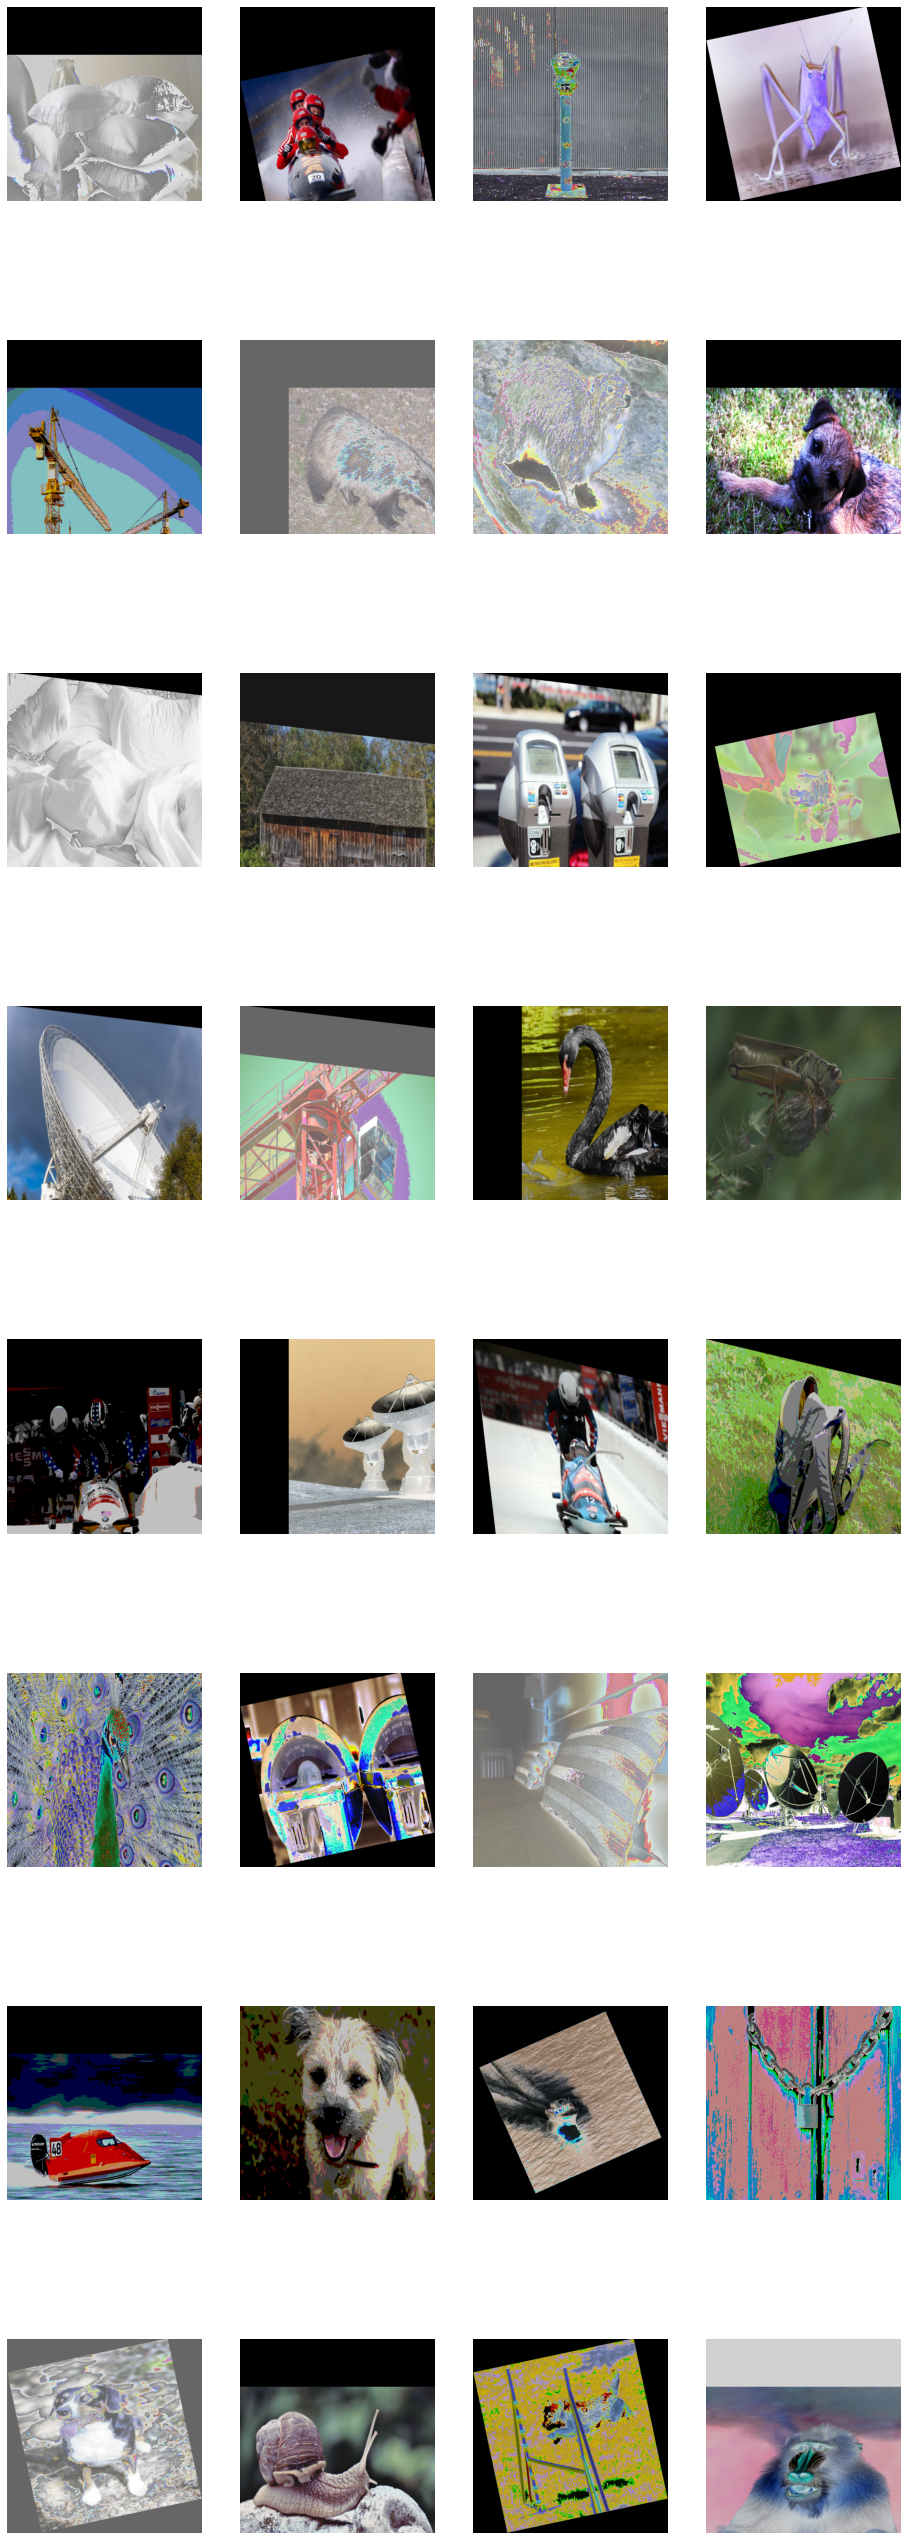

In [14]:
display_imgs(out, columns=4)